In [ ]:
# ==========================================
# 1. Mount Google Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 2. Setup Directories
# ==========================================
import os
BASE_DIR = "/content/drive/MyDrive/coin_project"
DATASET_DIR = f"{BASE_DIR}/dataset"
MODEL_PATH = f"{BASE_DIR}/best_model_multiclass.pth"

In [ ]:
# ==========================================
# 3. Imports
# ==========================================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import json
import cv2
import random

In [ ]:
# ==========================================
# 4. Transforms
# ==========================================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1), shear=5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# ==========================================
# 4.5 COCO → Classification Conversion
# ==========================================
def convert_coco_to_classification(coco_json_path, images_dir, output_dir):
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # Map category IDs to class names
    categories = {cat['id']: cat['name'] for cat in coco['categories']}

    # Map image IDs to filenames
    images_map = {img['id']: img['file_name'] for img in coco['images']}

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    for ann in coco['annotations']:
        img_id = ann['image_id']
        cat_id = ann['category_id']
        bbox = ann['bbox']  # [x, y, w, h]

        img_name = images_map[img_id]
        class_name = categories[cat_id]

        image_path = os.path.join(images_dir, img_name)
        img = cv2.imread(image_path)
        if img is None:
            continue

        x, y, w, h = map(int, bbox)
        pad = 5  # optional padding
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w + 2 * pad, img.shape[1] - x)
        h = min(h + 2 * pad, img.shape[0] - y)

        crop = img[y:y+h, x:x+w]
        if crop.size == 0:
            continue

        # Save crop into class folder
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        base_name = os.path.splitext(img_name)[0]
        save_name = f"{base_name}_{ann['id']}.jpg"
        save_path = os.path.join(class_dir, save_name)
        cv2.imwrite(save_path, crop)

    print(f"✅ Conversion done for {output_dir}")

# ==========================================
# Run conversion for all splits
# ==========================================
splits = ["train", "valid", "test"]

for split in splits:
    coco_json_path = f"{BASE_DIR}/dataset/{split}/_annotations.coco.json"
    images_dir     = f"{BASE_DIR}/dataset/{split}"
    output_dir     = f"{BASE_DIR}/{split}_cls"

    if not os.path.exists(output_dir) or len(os.listdir(output_dir)) == 0:
        convert_coco_to_classification(coco_json_path, images_dir, output_dir)
    else:
        print(f"✅ {split}_cls already exists, skipping conversion.")

✅ train_cls already exists, skipping conversion.
✅ valid_cls already exists, skipping conversion.
✅ test_cls already exists, skipping conversion.


In [ ]:
# ==========================================
# 5. Dataset
# ==========================================
train_dataset = ImageFolder(f"{BASE_DIR}/train_cls", transform=train_transforms)
val_dataset   = ImageFolder(f"{BASE_DIR}/valid_cls", transform=val_test_transforms)
test_dataset  = ImageFolder(f"{BASE_DIR}/test_cls", transform=val_test_transforms)

# =================================
# Data loaders (Batch size = 32)
# =================================
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = torch.tensor(
    [sum(class_counts)/c for c in class_counts],
    dtype=torch.float
).to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

classes = train_dataset.classes
print("Classes:", classes)

Classes: ['1 peso new', '1 peso old', '10 peso new', '10 peso old', '20 peso', '5 peso new', '5 peso old']


In [ ]:
# =============================================
# 6. Model (Dropout = 0.5 / Freeze Backbone)
# =============================================
class CoinClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5, freeze_backbone=True, fine_tune_last=False):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Optional: fine-tune last block
        if fine_tune_last:
            for param in self.backbone.features[-1].parameters():
                param.requires_grad = True

        in_features = self.backbone.classifier[1].in_features
        # More powerful classifier head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate/2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = CoinClassifier(len(train_dataset.classes), fine_tune_last=True).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 156MB/s]


In [ ]:
# ====================================================
# 7. Loss & Optimizer (Adam | Learning rate = 1e-4)
# ====================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
# ======================================================
# 8. Training Loop (Epochs = 50 / Early Stopping = 7)
# ======================================================
def train_model(model, train_loader, val_loader, epochs=50, patience=7):
    best_val_loss = float('inf')
    counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), MODEL_PATH)
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

    return train_losses, val_losses, train_accs, val_accs

train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader)

Epoch 1: Train Acc=0.2649, Val Acc=0.4037
Epoch 2: Train Acc=0.4141, Val Acc=0.4587
Epoch 3: Train Acc=0.4487, Val Acc=0.4771
Epoch 4: Train Acc=0.4773, Val Acc=0.5229
Epoch 5: Train Acc=0.5310, Val Acc=0.5413
Epoch 6: Train Acc=0.5024, Val Acc=0.5321
Epoch 7: Train Acc=0.5310, Val Acc=0.6055
Epoch 8: Train Acc=0.5704, Val Acc=0.5963
Epoch 9: Train Acc=0.5597, Val Acc=0.6055
Epoch 10: Train Acc=0.5800, Val Acc=0.6239
Epoch 11: Train Acc=0.5847, Val Acc=0.6514
Epoch 12: Train Acc=0.5967, Val Acc=0.6606
Epoch 13: Train Acc=0.6193, Val Acc=0.6606
Epoch 14: Train Acc=0.6480, Val Acc=0.6789
Epoch 15: Train Acc=0.6193, Val Acc=0.7156
Epoch 16: Train Acc=0.6766, Val Acc=0.6972
Epoch 17: Train Acc=0.6563, Val Acc=0.7064
Epoch 18: Train Acc=0.6563, Val Acc=0.7339
Epoch 19: Train Acc=0.6659, Val Acc=0.7339
Epoch 20: Train Acc=0.6683, Val Acc=0.7339
Epoch 21: Train Acc=0.6742, Val Acc=0.7339
Epoch 22: Train Acc=0.6647, Val Acc=0.7248
Epoch 23: Train Acc=0.6814, Val Acc=0.7431
Epoch 24: Train Acc=

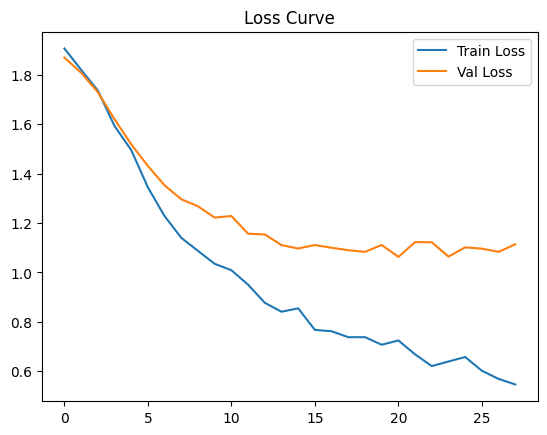

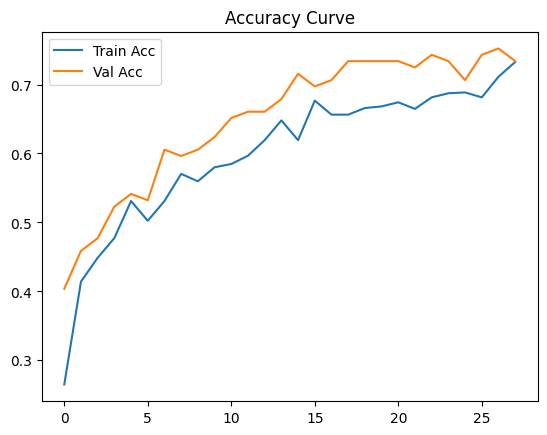

In [ ]:
# ==========================================
# 9. Plot Training Progress
# ==========================================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


Classification Report:
              precision    recall  f1-score   support

  1 peso new       0.74      0.49      0.59        35
  1 peso old       0.70      0.81      0.75        32
 10 peso new       0.60      0.75      0.67         4
 10 peso old       0.33      1.00      0.50         1
     20 peso       1.00      1.00      1.00         5
  5 peso new       0.67      0.91      0.77        11
  5 peso old       0.67      0.67      0.67         3

    accuracy                           0.70        91
   macro avg       0.67      0.80      0.71        91
weighted avg       0.72      0.70      0.70        91



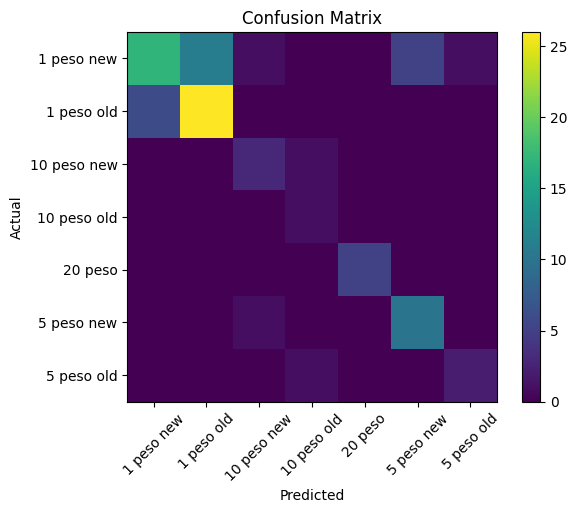

In [ ]:
# ==========================================
# 10. Evaluation + Confusion Matrix
# ==========================================
def evaluate(model, test_loader, classes):
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks(range(len(classes)), classes, rotation=45)
    plt.yticks(range(len(classes)), classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate(model, test_loader, classes)

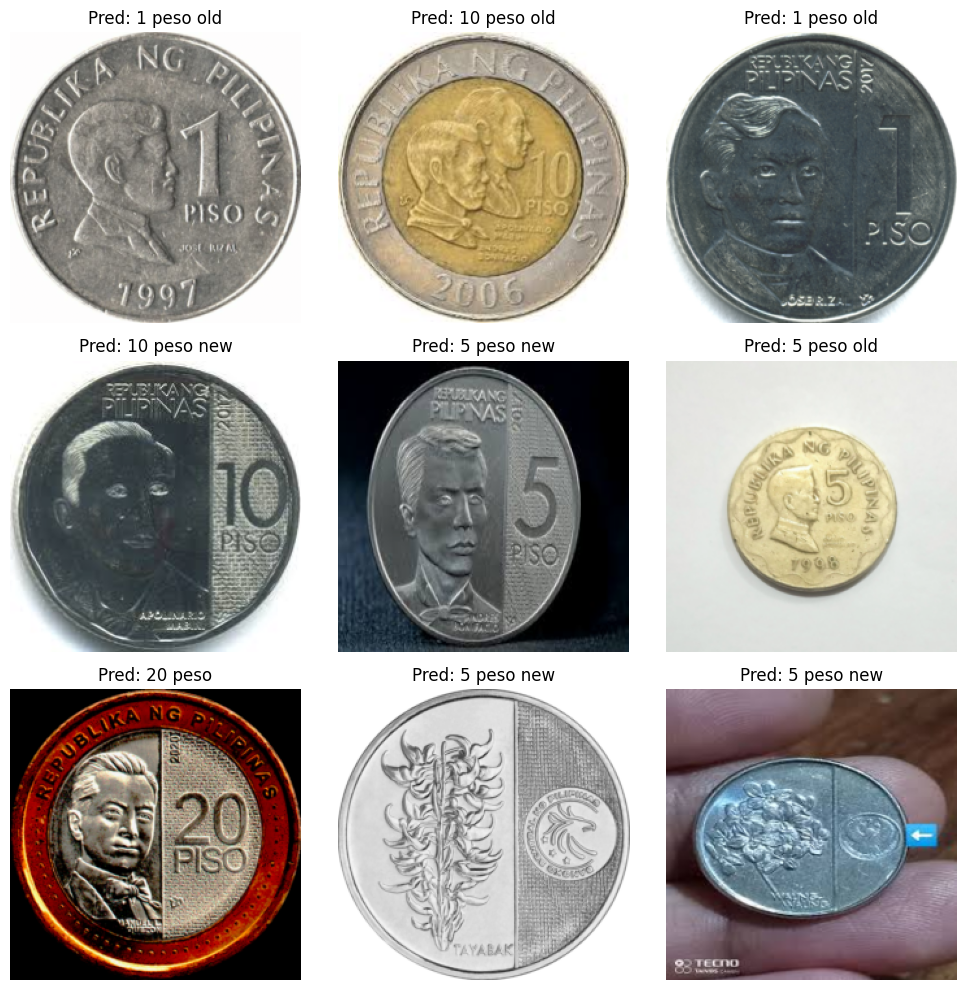

In [ ]:
# ==========================================
# 11. True vs Pred Visualization
# ==========================================
def show_predictions_from_folder(model, images_dir, classes, num_images=9, transform=None):
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    # Get all image files
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled_files = random.sample(image_files, min(num_images, len(image_files)))

    plt.figure(figsize=(10, 10))

    for i, img_file in enumerate(sampled_files):
        img_path = os.path.join(images_dir, img_file)
        img = Image.open(img_path).convert("RGB")

        if transform:
            input_img = transform(img).unsqueeze(0).to(device)
        else:
            input_img = transforms.ToTensor()(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            pred = torch.argmax(output, dim=1).item()

        # Correct color: undo normalization
        unnormalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )

        img_tensor = input_img.squeeze(0).cpu()  # remove batch dim
        img_tensor = unnormalize(img_tensor)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = img_np.clip(0, 1)

        plt.subplot(3, 3, i+1)
        plt.imshow(img_np)
        plt.title(f"Pred: {classes[pred]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions_from_folder(model, f"{BASE_DIR}/dataset", classes, num_images=9, transform=val_test_transforms)